# Classificação da informalidade na Paraíba

**Integrantes:** Bruno Marque e Vitória Emanuele  
**Disciplina:** Aprendizagem de Máquina — UFPB, 2026.1  
**Fonte:** PNAD Contínua Trimestral, IBGE — quatro trimestres de 2024. 

In [52]:
import pandas as pd
import matplotlib.pyplot as plt  
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, recall_score, classification_report
from sklearn.model_selection import StratifiedKFold
from keras.models import Sequential
from keras.layers import Dense, Input, Dropout
from keras.callbacks import EarlyStopping
from keras import regularizers

## 1. Dataset:

In [53]:
df = pd.read_csv('dados/pnad/pnad_paraiba_2024.csv')
print(f"Registros carregados: {len(df)}")
print(df.dtypes)


Registros carregados: 19550
id_domicilio                     str
id_pessoa                        str
trimestre_num                  int64
numero_entrevistas_pessoa      int64
peso_pessoa                  float64
capital                        int64
situacao_urbana_rural          int64
tipo_area                      int64
peso_amostral                float64
sexo                           int64
idade                          int64
cor_raca                       int64
nivel_instrucao                int64
numero_trabalhos               int64
area_trabalho                float64
grupo_atividade                int64
grupo_ocupacao                 int64
rendimento_habitual          float64
horas_habituais                int64
target_informal                int64
dtype: object


### 1.2 Dicionário resumido

- `id_domicilio`, `id_pessoa`: identificadores.
- `trimestre_num`: qual trimestre de 2024.
- `numero_entrevistas_pessoa`: quantas vezes a pessoa foi entrevistada.
- `peso_pessoa`, `peso_amostral`: pesos estatísticos da amostra (pra representar a população real), é usado como 'sample_weight'.
- `capital`, `situacao_urbana_rural`, `tipo_area`: geografia.
- `sexo`, `idade`, `cor_raca`: demografia.
- `nivel_instrucao`: escolaridade.
- `numero_trabalhos`: quantos empregos tem.
- `area_trabalho`, `grupo_atividade`, `grupo_ocupacao`: particularidades da ocupação dos entrevistados.
- `rendimento_habitual`: quanto ganha.
- `horas_habituais`: quantas horas trabalha.
- `target_informal`: 0 = formal, 1 = informal.

## 2. Engenharia de atributos:

Para a construção da matriz de atributos (X), foram removidas do conjunto original as colunas que não representam características preditivas da pessoa, por pertencerem a três categorias distintas:

- Identificadores e metadados de coleta: `id_domicilio` e `id_pessoa` são apenas chaves de identificação, sem valor preditivo.
- `trimestre_num` foi descartada por representar tempo (o objetivo é caracterizar a pessoa, não o período da entrevista)
- `numero_entrevistas_pessoa` é um metadado do desenho amostral, não uma característica do indivíduo.

- Pesos amostrais: `peso_pessoa` e `peso_amostral` não são atributos de entrada, mas pesos estatísticos da PNAD que indicam quantas pessoas da população cada entrevista representa. Por isso, não entram em X — são utilizados separadamente como sample_weight no treinamento e na avaliação dos modelos, garantindo que as métricas reflitam a população real da Paraíba, e não apenas a amostra coletada.

- `area_trabalho`: carregara informação sobre a condição de informalidade da pessoa. Manter essa coluna, mesmo com imputação, criaria risco de vazamento de dados (data leakage), pois o modelo poderia aprender a associar "valor ausente" a "informal" por um artefato da coleta, e não por uma relação causal real.

In [83]:
X = df[["idade", "numero_trabalhos", "rendimento_habitual", "horas_habituais",
        "capital", "situacao_urbana_rural", "tipo_area",
        "sexo", "cor_raca", "nivel_instrucao", "grupo_atividade", "grupo_ocupacao"]].copy()
y = df["target_informal"].copy()

N_total, p_total = X.shape
print(f"Número total de amostras (N): {N_total}")
print(f"Número de atributos/parâmetros de entrada (p): {p_total}")

Número total de amostras (N): 19550
Número de atributos/parâmetros de entrada (p): 12


## 3. Separação treino/teste:

No conjunto de dados, uma mesma pessoa pode figurar em mais de uma linha, por ter sido entrevistada em diferentes trimestres de 2024 — de fato, as 19.550 linhas correspondem a apenas 9.166 pessoas distintas. Um `train_test_split` convencional poderia alocar entrevistas da mesma pessoa (ou do mesmo domicílio) simultaneamente no treino e no teste, permitindo que o modelo memorizasse características individuais em vez de aprender padrões generalizáveis — um vazamento de dados por agrupamento.

Para evitar esse problema, utilizou-se o `StratifiedGroupKFold`, agrupando as observações por `id_domicilio`. Essa técnica garante que todas as entrevistas de um mesmo domicílio permaneçam inteiramente no treino ou inteiramente no teste, ao mesmo tempo em que preserva a proporção original das classes (`target_informal`) em ambos os conjuntos — combinando, portanto, agrupamento e estratificação em uma única divisão.

In [84]:
n_linhas = len(df)
n_pessoas_unicas = df["id_pessoa"].nunique()
n_domicilios_unicos = df["id_domicilio"].nunique()

print(f"Número de linhas (entrevistas): {n_linhas}")
print(f"Número de pessoas únicas: {n_pessoas_unicas}")
print(f"Número de domicílios únicos: {n_domicilios_unicos}")
print(f"\nEm média, cada pessoa aparece {n_linhas / n_pessoas_unicas:.2f} vezes no dataset")

contagem_por_pessoa = df["id_pessoa"].value_counts()
pessoas_repetidas = (contagem_por_pessoa > 1).sum()
print(f"Pessoas que aparecem em mais de um trimestre: {pessoas_repetidas} ({pessoas_repetidas / n_pessoas_unicas:.1%} do total)")

Número de linhas (entrevistas): 19550
Número de pessoas únicas: 9166
Número de domicílios únicos: 5737

Em média, cada pessoa aparece 2.13 vezes no dataset
Pessoas que aparecem em mais de um trimestre: 5770 (63.0% do total)


In [ ]:
from sklearn.model_selection import StratifiedGroupKFold

grupos = df["id_domicilio"].copy()

divisor = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
indice_treino, indice_teste = next(divisor.split(X, y, groups=grupos))

X_train = X.iloc[indice_treino].reset_index(drop=True)
X_test  = X.iloc[indice_teste].reset_index(drop=True)
y_train = y.iloc[indice_treino].reset_index(drop=True)
y_test  = y.iloc[indice_teste].reset_index(drop=True)

grupos_train = grupos.iloc[indice_treino].reset_index(drop=True)

print(f"Treino: {len(X_train)} amostras")
print(f"Teste: {len(X_test)} amostras")
print("\nDistribuição treino:")
print(y_train.value_counts(normalize=True).round(3))
print("\nDistribuição teste:")
print(y_test.value_counts(normalize=True).round(3))

Treino: 15638 amostras
Teste: 3912 amostras

Distribuição treino:
target_informal
1    0.521
0    0.479
Name: proportion, dtype: float64

Distribuição teste:
target_informal
1    0.521
0    0.479
Name: proportion, dtype: float64


## 4. Pré processamento e normalização:

### 4.1 Imputação de dados:

In [86]:
from sklearn.impute import SimpleImputer

COLUNAS_NUMERICAS = ["idade", "numero_trabalhos", "rendimento_habitual", "horas_habituais"]
COLUNAS_CATEGORICAS = ["capital", "situacao_urbana_rural", "tipo_area", "sexo", "cor_raca", "nivel_instrucao", "grupo_atividade", "grupo_ocupacao"]

imputador_numerico = SimpleImputer(strategy="median")

X_train_num_imputado = imputador_numerico.fit_transform(X_train[COLUNAS_NUMERICAS])
X_test_num_imputado = imputador_numerico.transform(X_test[COLUNAS_NUMERICAS])

print("Mediana aprendida no treino (por coluna):")
print(dict(zip(COLUNAS_NUMERICAS, imputador_numerico.statistics_)))

imputador_categorico = SimpleImputer(strategy="most_frequent")

X_train_cat_imputado = imputador_categorico.fit_transform(X_train[COLUNAS_CATEGORICAS])
X_test_cat_imputado = imputador_categorico.transform(X_test[COLUNAS_CATEGORICAS])

print("\nModa aprendida no treino (por coluna):")
print(dict(zip(COLUNAS_CATEGORICAS, imputador_categorico.statistics_)))

print("\nNulos restantes (numéricas, treino):", pd.DataFrame(X_train_num_imputado).isnull().sum().sum())
print("Nulos restantes (categóricas, treino):", pd.DataFrame(X_train_cat_imputado).isnull().sum().sum())

Mediana aprendida no treino (por coluna):
{'idade': np.float64(40.0), 'numero_trabalhos': np.float64(1.0), 'rendimento_habitual': np.float64(1412.0), 'horas_habituais': np.float64(40.0)}

Moda aprendida no treino (por coluna):
{'capital': np.float64(0.0), 'situacao_urbana_rural': np.float64(1.0), 'tipo_area': np.float64(4.0), 'sexo': np.float64(1.0), 'cor_raca': np.float64(4.0), 'nivel_instrucao': np.float64(5.0), 'grupo_atividade': np.float64(4.0), 'grupo_ocupacao': np.float64(5.0)}

Nulos restantes (numéricas, treino): 0
Nulos restantes (categóricas, treino): 0


### 4.2 One hot encoding:

In [87]:
from sklearn.preprocessing import OneHotEncoder

onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_train_cat_encoded = onehot.fit_transform(X_train_cat_imputado)
X_test_cat_encoded = onehot.transform(X_test_cat_imputado)

nomes_colunas_encoded = onehot.get_feature_names_out(COLUNAS_CATEGORICAS)

print(f"Colunas categóricas originais: {len(COLUNAS_CATEGORICAS)}")
print(f"Colunas após one-hot: {X_train_cat_encoded.shape[1]}")
print("\nExemplo de nomes gerados:")
print(list(nomes_colunas_encoded[:10]))

Colunas categóricas originais: 8
Colunas após one-hot: 42

Exemplo de nomes gerados:
['capital_0', 'capital_1', 'situacao_urbana_rural_1', 'situacao_urbana_rural_2', 'tipo_area_1', 'tipo_area_2', 'tipo_area_4', 'sexo_1', 'sexo_2', 'cor_raca_1']


### 4.3 Normalização:

In [89]:
scaler = StandardScaler()

X_train_num_scaled = scaler.fit_transform(X_train_num_imputado)
X_test_num_scaled = scaler.transform(X_test_num_imputado)

### 4.4 Junção das duas matrizes normalizadas:

In [90]:
X_train_processado = np.hstack([X_train_num_scaled, X_train_cat_encoded])
X_test_processado = np.hstack([X_test_num_scaled, X_test_cat_encoded])


## 5. Rede neural:

In [91]:
N, p = X_train_processado.shape
print(f"Número total de amostras (N): {N}")
print(f"Número de atributos/parâmetros de entrada (p): {p}")

Número total de amostras (N): 15638
Número de atributos/parâmetros de entrada (p): 46


Para definir o número de neurônios da camada oculta de forma não arbitrária, utilizamos a Teoria da Generalização do Aprendizado, através da Dimensão Vapnik-Chervonenkis ($d_{VC}$): $$d_{VC, max} = \frac{N_{treino}}{10}$$


A ideia central é limitar a complexidade do modelo a um valor compatível com a quantidade de dados disponíveis para treino, evitando overfitting por excesso de parâmetros.

Para uma rede neural com uma única camada oculta totalmente conectada, com (p) atributos de entrada e (h) neurônios na camada oculta (seguida de 1 neurônio de saída), o número de parâmetros treináveis — e, por consequência, uma estimativa da sua dimensão VC — é dado por: $$d_{VC}​≈(p+1)⋅h+(h+1)=(p+2)⋅h+1$$


Isolando (h) e substituindo ($d_{VC}$) pelo limite máximo permitido, obtemos o teto teórico de neurônios para a camada oculta:

$$h_{max}​= \frac{d_{VC,max}​−1}{p+2}​$$

In [92]:

d_VC_max = N / 10

h_max = (d_VC_max - 1) / ( p + 1 + 1)

print(f"Número de amostras (N): {N}")
print(f"Dimensão VC máxima permitida (d_VC): {d_VC_max:.2f}") 
print(f"Teto teórico de neurônio para 1 camada (h_max): {h_max:.4f}")

Número de amostras (N): 15638
Dimensão VC máxima permitida (d_VC): 1563.80
Teto teórico de neurônio para 1 camada (h_max): 32.5583


### 5.1 Configuração da rede neural:

In [93]:
model = Sequential()
model.add(Input(shape=(p,))) 

model.add(Dense(32, kernel_initializer='he_normal', activation='relu'))
model.add(Dense(1, kernel_initializer='glorot_normal', activation='sigmoid'))

initial_weights = model.get_weights() 
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
print(model.summary())


Model: "sequential_94"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_188 (Dense)               │ (None, 32)             │         1,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_189 (Dense)               │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

None


### 5.2 Teste de Batch Size:

In [63]:
from tensorflow.keras.callbacks import EarlyStopping

callback = EarlyStopping(
    monitor='val_loss', 
    patience=10,        
    restore_best_weights=True 
)

for batch in [8, 16, 32, 64]:
    print(f"Testando Batch Size: {batch}")
    model.set_weights(initial_weights)
    history = model.fit(
        X_train_processado, y_train,
        validation_split=0.2, 
        epochs=200,          
        batch_size=batch,
        callbacks=[callback],
        verbose=0
    )
    print(f"Treinamento parado na época: {len(history.history['loss'])}")
    print(f"Melhor Eout encontrado: {min(history.history['val_loss']):.4f}\n")

Testando Batch Size: 8
Treinamento parado na época: 30
Melhor Eout encontrado: 0.3286

Testando Batch Size: 16
Treinamento parado na época: 10
Melhor Eout encontrado: 0.3413

Testando Batch Size: 32
Treinamento parado na época: 10
Melhor Eout encontrado: 0.3462

Testando Batch Size: 64
Treinamento parado na época: 10
Melhor Eout encontrado: 0.3530



In [64]:
model.set_weights(initial_weights)

history = model.fit(
    X_train_processado, y_train, 
    validation_split= 0.2,
    epochs=200, 
    batch_size=64, 
    callbacks=[callback],
    verbose=1
)


Epoch 1/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7499 - loss: 0.5147 - val_accuracy: 0.8063 - val_loss: 0.4340
Epoch 2/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8106 - loss: 0.4075 - val_accuracy: 0.8152 - val_loss: 0.4004
Epoch 3/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8190 - loss: 0.3877 - val_accuracy: 0.8267 - val_loss: 0.3875
Epoch 4/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8247 - loss: 0.3759 - val_accuracy: 0.8344 - val_loss: 0.3780
Epoch 5/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8303 - loss: 0.3668 - val_accuracy: 0.8373 - val_loss: 0.3719
Epoch 6/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8345 - loss: 0.3591 - val_accuracy: 0.8421 - val_loss: 0.3668
Epoch 7/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8398 - loss: 0.3528 - val_accuracy: 0.8440 - val_loss: 0.3595
Epoch 8/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8429 - loss: 0.3474 - val_accu

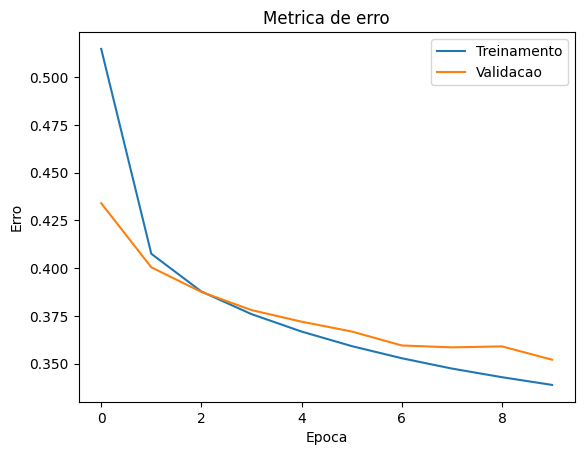

--> E_out - E_in = 0.0100
--> Acuracia (treino): 0.8046
--> Acuracia (teste): 0.7906
--> acc_train - acc_test = 0.0140


In [65]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Metrica de erro')
plt.ylabel('Erro')
plt.xlabel('Epoca')
plt.legend(['Treinamento', 'Validacao'])
plt.show()

ein, acc_train = model.evaluate(X_train_processado, y_train, verbose=0)
eout, acc_test = model.evaluate(X_test_processado, y_test, verbose=0)

print(f"--> E_out - E_in = {eout - ein:.4f}")
print(f'--> Acuracia (treino): {acc_train:.4f}')
print(f'--> Acuracia (teste): {acc_test:.4f}')
print(f"--> acc_train - acc_test = {acc_train - acc_test:.4f}")

In [66]:
y_pred_prob = model.predict(X_test_processado)
y_pred = (y_pred_prob > 0.5).astype(int)

print("=== Métricas de Qualidade (Rede Neural) ===")
print(f"Acurácia: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred, target_names=['Formal(0)', 'Informal (1)']))

123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
=== Métricas de Qualidade (Rede Neural) ===
Acurácia: 0.7906

              precision    recall  f1-score   support

   Formal(0)       0.79      0.77      0.78      1874
Informal (1)       0.79      0.81      0.80      2038

    accuracy                           0.79      3912
   macro avg       0.79      0.79      0.79      3912
weighted avg       0.79      0.79      0.79      3912



### 5.3 Regulazição com Grid Search Manual + Validação (K-Fold Cross Validation) :

In [ ]:
from itertools import product


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    "l2_reg": [0.001, 0.01, 0.1],
    "dropout": [0.1, 0.2, 0.3],
    "batch_size": [64], 
    "epochs": [100]
}

param_combinations = list(product(*param_grid.values()))
param_names = list(param_grid.keys())

best_val_acc = -1
best_params = None

print("Iniciando Grid Search Manual com K-Fold Integrado...\n")

for combo in param_combinations:
    params = dict(zip(param_names, combo))
    print(f"===== Testando parâmetros: {params} =====")

    accuracies_train = []
    accuracies_val = []

    i = 0
    for train_index, val_index in skf.split(X_train_processado, y_train):
        i += 1
        X_train_fold, X_val_fold = X_train_processado[train_index], X_train_processado[val_index]
        y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

        model = Sequential()
        model.add(Input(shape=(p,)))

        model.add(Dense(32, kernel_initializer='he_normal',
                        kernel_regularizer=regularizers.l2(params["l2_reg"]),
                        activation='relu'))

        if params["dropout"] > 0:
            model.add(Dropout(params["dropout"]))

        model.add(Dense(1, kernel_initializer='glorot_normal', activation='sigmoid'))

        model.compile(loss='binary_crossentropy', optimizer="adam", metrics=['accuracy'])
        
        es = EarlyStopping(monitor='val_loss', mode='min', verbose=0, patience=10, restore_best_weights=True)

        history = model.fit(X_train_fold, y_train_fold,
                            validation_data=(X_val_fold, y_val_fold),
                            epochs=params["epochs"], 
                            batch_size=params["batch_size"], 
                            callbacks=[es],
                            verbose=0)

        E_in, accuracy_train = model.evaluate(X_train_fold, y_train_fold, batch_size=params["batch_size"], verbose=0)
        E_val, accuracy_val = model.evaluate(X_val_fold, y_val_fold, batch_size=params["batch_size"], verbose=0)

        accuracies_train.append(accuracy_train)
        accuracies_val.append(accuracy_val)

    avg_accuracy_train = np.mean(accuracies_train)
    avg_accuracy_val = np.mean(accuracies_val)

    print(f">>> Avg train acc = {avg_accuracy_train:.4f} | Avg val acc = {avg_accuracy_val:.4f}\n")

    if avg_accuracy_val > best_val_acc:
        best_val_acc = avg_accuracy_val
        best_params = params

print("==============================")
print(f"Melhores parâmetros encontrados: {best_params}")
print(f"Melhor acurácia na validação (Média do K-Fold): {best_val_acc:.4f}")

Iniciando Grid Search Manual com K-Fold Integrado...

===== Testando parâmetros: {'l2_reg': 0.001, 'dropout': 0.1, 'batch_size': 64, 'epochs': 100} =====
>>> Avg train acc = 0.8727 | Avg val acc = 0.8575

===== Testando parâmetros: {'l2_reg': 0.001, 'dropout': 0.2, 'batch_size': 64, 'epochs': 100} =====
>>> Avg train acc = 0.8711 | Avg val acc = 0.8577

===== Testando parâmetros: {'l2_reg': 0.001, 'dropout': 0.3, 'batch_size': 64, 'epochs': 100} =====
>>> Avg train acc = 0.8690 | Avg val acc = 0.8559

===== Testando parâmetros: {'l2_reg': 0.01, 'dropout': 0.1, 'batch_size': 64, 'epochs': 100} =====
>>> Avg train acc = 0.8580 | Avg val acc = 0.8506

===== Testando parâmetros: {'l2_reg': 0.01, 'dropout': 0.2, 'batch_size': 64, 'epochs': 100} =====
>>> Avg train acc = 0.8594 | Avg val acc = 0.8518

===== Testando parâmetros: {'l2_reg': 0.01, 'dropout': 0.3, 'batch_size': 64, 'epochs': 100} =====
>>> Avg train acc = 0.8569 | Avg val acc = 0.8502

===== Testando parâmetros: {'l2_reg': 0.1, 

#### Retreinando o modelo:

In [ ]:
print("\nTreinando a rede com os melhores parâmetros no conjunto de treinamento completo...")
model_final = Sequential()
model_final.add(Input(shape=(p,)))
model_final.add(Dense(32, kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(best_params["l2_reg"]), activation='relu'))


if best_params["dropout"] > 0:
    model_final.add(Dropout(best_params["dropout"]))

model_final.add(Dense(1, kernel_initializer='glorot_normal', activation='sigmoid'))
model_final.compile(loss='binary_crossentropy', optimizer="adam", metrics=['accuracy'])

es_final = EarlyStopping(monitor='val_loss', mode='min', verbose=0, patience=10, restore_best_weights=True)
history_final = model_final.fit(X_train_processado, y_train,
        validation_split=0.2,                
        epochs=best_params["epochs"],
        batch_size=best_params["batch_size"],
        callbacks=[es_final],
        verbose=0)

E_in, acc_train = model_final.evaluate(X_train_processado, y_train, batch_size=best_params["batch_size"], verbose=0)
print(f"\nTrain set -> Loss: {E_in:.4f}, Accuracy: {acc_train:.4f}")

E_test, acc_test = model_final.evaluate(X_test_processado, y_test, batch_size=best_params["batch_size"], verbose=0)
print(f"\nTest set -> Loss: {E_test:.4f}, Accuracy: {acc_test:.4f}")


Treinando a rede com os melhores parâmetros no conjunto de treinamento completo...

Train set -> Loss: 0.3132, Accuracy: 0.8722

Test set -> Loss: 0.3597, Accuracy: 0.8515


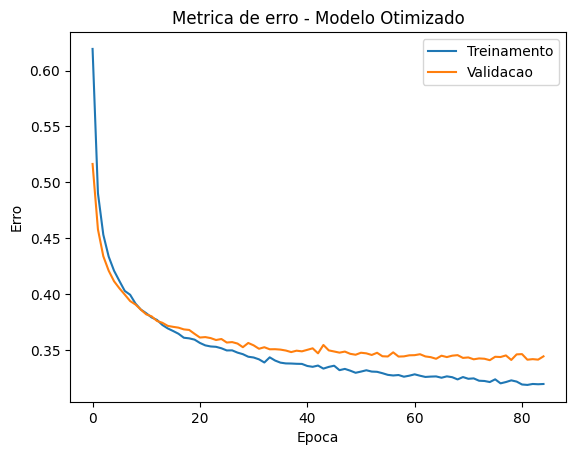

In [69]:
plt.plot(history_final.history['loss'])
plt.plot(history_final.history['val_loss'])
plt.title('Metrica de erro - Modelo Otimizado')
plt.ylabel('Erro')
plt.xlabel('Epoca')
plt.legend(['Treinamento', 'Validacao'])
plt.show()

In [70]:
y_pred_prob = model_final.predict(X_test_processado)
y_pred = (y_pred_prob > 0.5).astype(int)

print("=== Métricas de Qualidade (Rede Neural Otimizada) ===")
print(f"Acurácia: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred, target_names=['Formal(0)', 'Informal (1)']))

123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
=== Métricas de Qualidade (Rede Neural Otimizada) ===
Acurácia: 0.8515

              precision    recall  f1-score   support

   Formal(0)       0.82      0.88      0.85      1874
Informal (1)       0.88      0.82      0.85      2038

    accuracy                           0.85      3912
   macro avg       0.85      0.85      0.85      3912
weighted avg       0.85      0.85      0.85      3912



## 6. Árvore de decisão:

### 6.1 Árvore pura:

In [94]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

model_tree = DecisionTreeClassifier(criterion='entropy', random_state=42)

model_tree.fit(X_train_processado, y_train)

ein_tree = 1 - model_tree.score(X_train_processado, y_train)
eout_tree = 1 - model_tree.score(X_test_processado, y_test)

print(f"Erro de Treinamento (Ein): {ein_tree:.4f}")
print(f"Erro de Teste (Eout): {eout_tree:.4f}")

Erro de Treinamento (Ein): 0.0045
Erro de Teste (Eout): 0.1961


In [95]:
nomes_colunas_final = COLUNAS_NUMERICAS + list(onehot.get_feature_names_out(COLUNAS_CATEGORICAS))

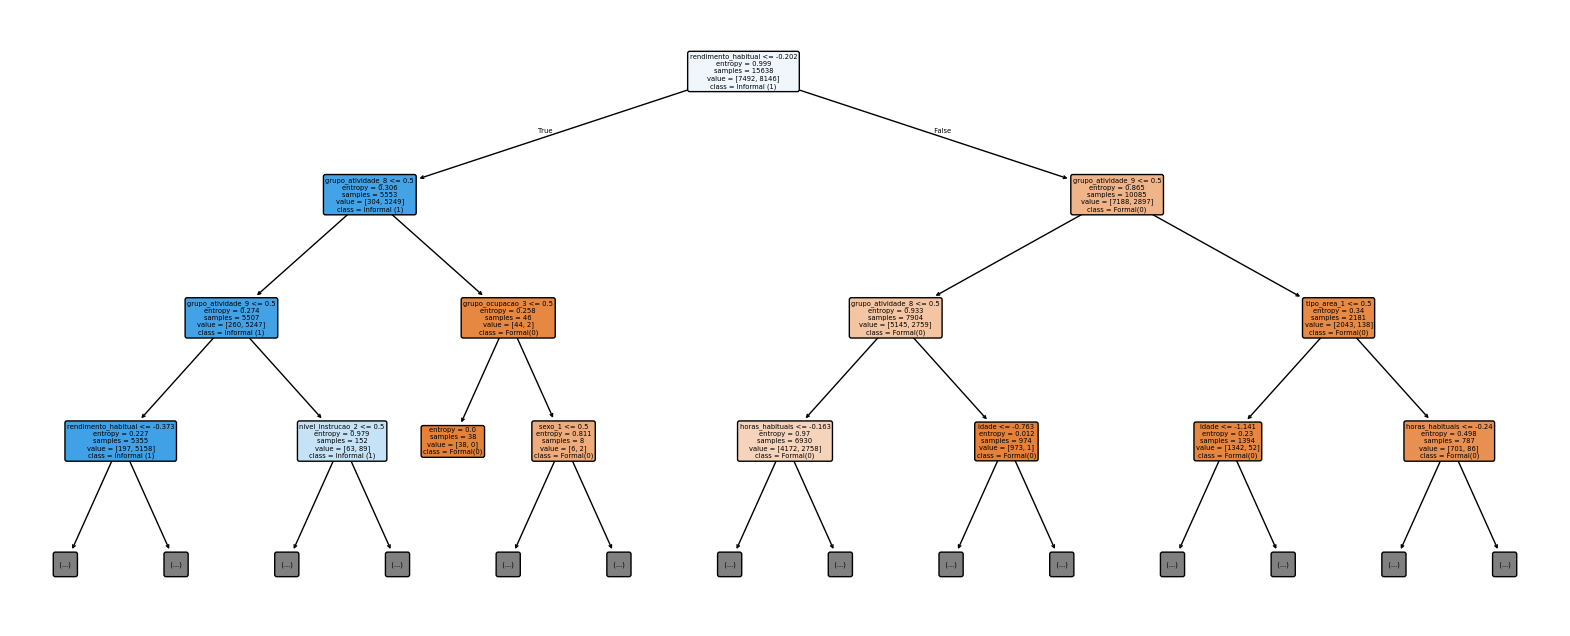

In [96]:
plt.figure(figsize=(20, 8))
tree.plot_tree(model_tree, 
               feature_names= nomes_colunas_final,
               class_names=['Formal(0)', 'Informal (1)'],
               filled=True, 
               rounded=True,
               max_depth=3)
plt.show()

### 6.2 Regularização Minimal Cost-Complexity Pruning via validação cruzada:

In [97]:

path = model_tree.cost_complexity_pruning_path(X_train_processado, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

print(f"Número de valores de alpha encontrados: {len(ccp_alphas)}")

Número de valores de alpha encontrados: 1073


In [98]:
from sklearn.model_selection import cross_val_score

alpha_loop_values = []

for alpha in np.linspace(ccp_alphas.min(), ccp_alphas.max()):
    model_pruned = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)

    scores = cross_val_score(model_pruned, X_train_processado, y_train, cv=5)
    alpha_loop_values.append([alpha, np.mean(scores)])

alpha_results = np.array(alpha_loop_values)

alphas_validos = alpha_results[alpha_results[:, 0] > 0.0005]
best_alpha = alphas_validos[np.argmax(alphas_validos[:, 1]), 0]


print(f"O Melhor Alpha encontrado foi (forçando): {best_alpha:.6f}")

O Melhor Alpha encontrado foi (forçando): 0.006777


In [99]:
tree_final = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
tree_final.fit(X_train_processado, y_train)

ein_final = 1 - tree_final.score(X_train_processado, y_train)
eout_final = 1 - tree_final.score(X_test_processado, y_test)

print(f"Novo Erro de Treinamento (Ein): {ein_final:.4f}")
print(f"Novo Erro de Teste (Eout): {eout_final:.4f}")

Novo Erro de Treinamento (Ein): 0.1667
Novo Erro de Teste (Eout): 0.1800


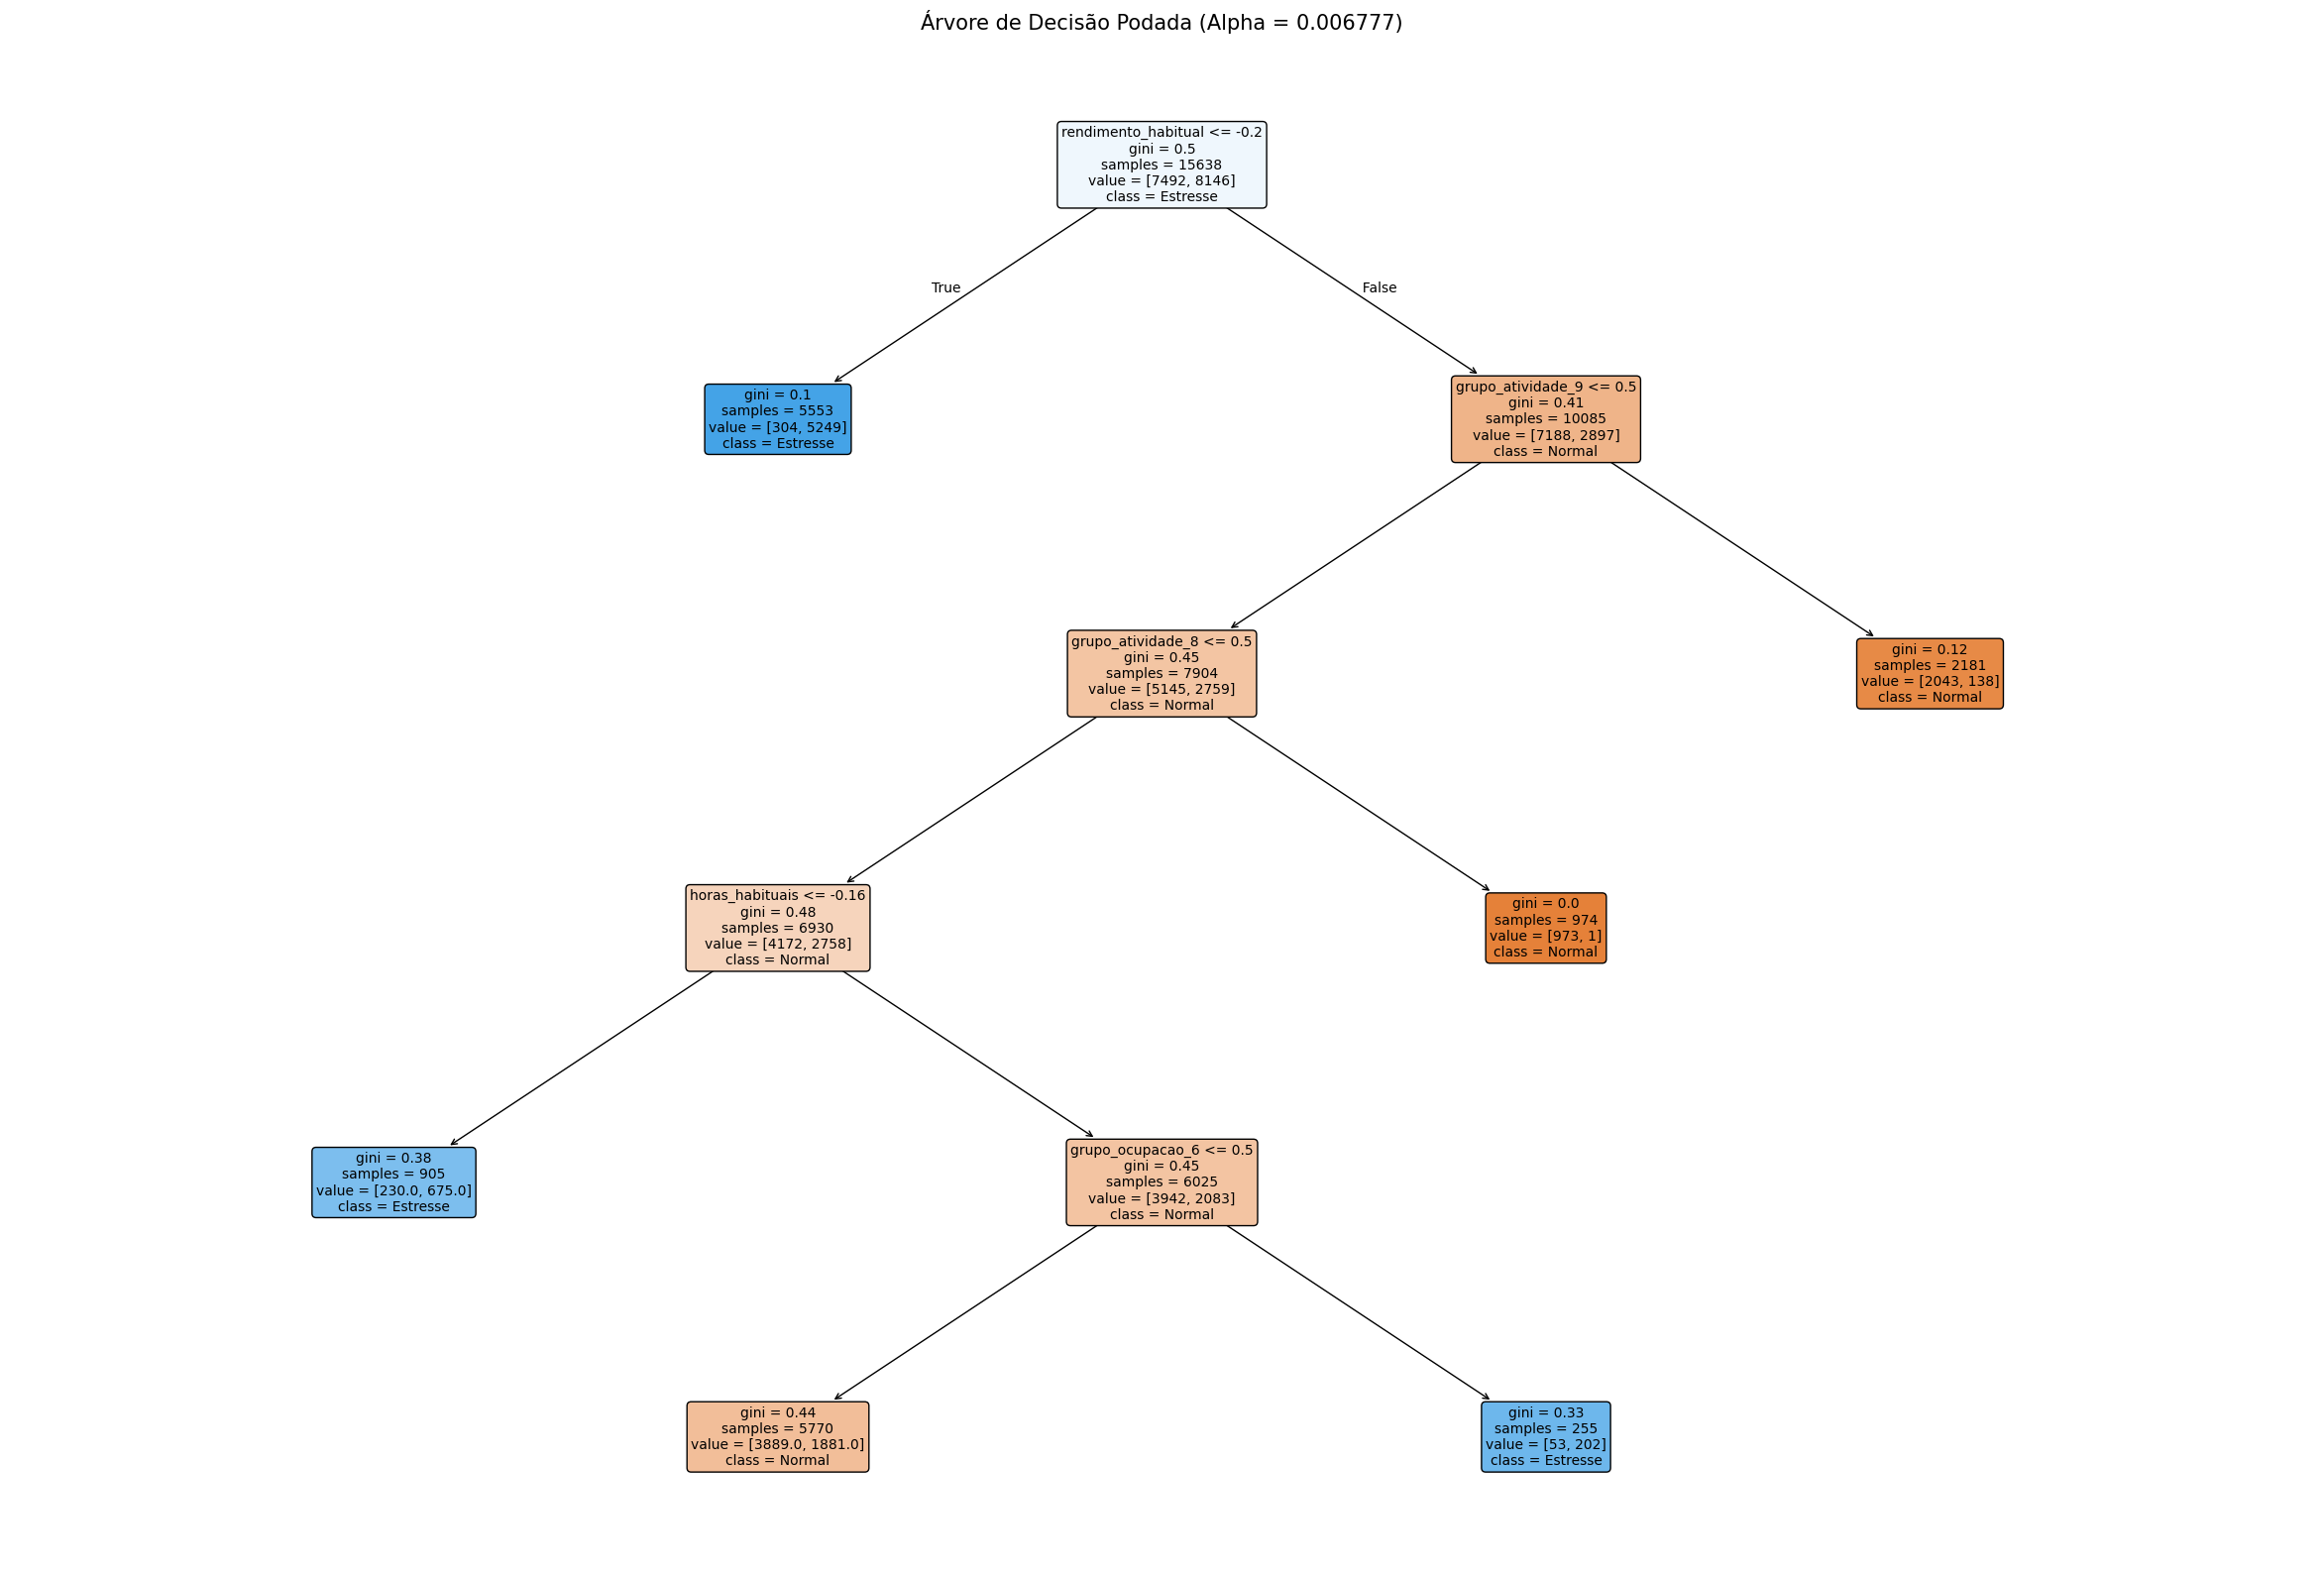

In [100]:
from sklearn.tree import plot_tree

plt.figure(figsize=(30, 20)) 

plot_tree(tree_final, 
          feature_names= nomes_colunas_final, 
          class_names=['(0) Formal', '(1) Informal'],
          filled=True,          
          rounded=True,         
          precision=2,         
          fontsize=10) 

plt.title(f"Árvore de Decisão Podada (Alpha = {best_alpha:.6f})", fontsize=15)
plt.show()

In [101]:
y_pred_tree = tree_final.predict(X_test_processado)

print("=== Métricas de Qualidade (Árvore de Decisão Podada) ===")
print(f"Acurácia: {accuracy_score(y_test, y_pred_tree):.4f}\n")
print(classification_report(y_test, y_pred_tree, target_names=['Formal (0)', 'Informal (1)']))

=== Métricas de Qualidade (Árvore de Decisão Podada) ===
Acurácia: 0.8200

              precision    recall  f1-score   support

  Formal (0)       0.75      0.93      0.83      1874
Informal (1)       0.92      0.72      0.81      2038

    accuracy                           0.82      3912
   macro avg       0.84      0.82      0.82      3912
weighted avg       0.84      0.82      0.82      3912



### 6.3 Random Forest:

In [102]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train_processado, y_train)

ein_rf = 1 - model_rf.score(X_train_processado, y_train)
eout_rf = 1 - model_rf.score(X_test_processado, y_test)

print(f"Erro de Treinamento da Floresta (Ein): {ein_rf:.4f}")
print(f"Erro de Teste da Floresta (Eout): {eout_rf:.4f}")

Erro de Treinamento da Floresta (Ein): 0.0045
Erro de Teste da Floresta (Eout): 0.1590


In [103]:
y_pred_rf = model_rf.predict(X_test_processado)

print("=== Métricas de Qualidade (Random Forest) ===")
print(f"Acurácia: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf, target_names=['Formal (0)', 'Informal (1)']))

=== Métricas de Qualidade (Random Forest) ===
Acurácia: 0.8410
              precision    recall  f1-score   support

  Formal (0)       0.82      0.86      0.84      1874
Informal (1)       0.86      0.82      0.84      2038

    accuracy                           0.84      3912
   macro avg       0.84      0.84      0.84      3912
weighted avg       0.84      0.84      0.84      3912



## 7. Compração entre os modelos:



123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


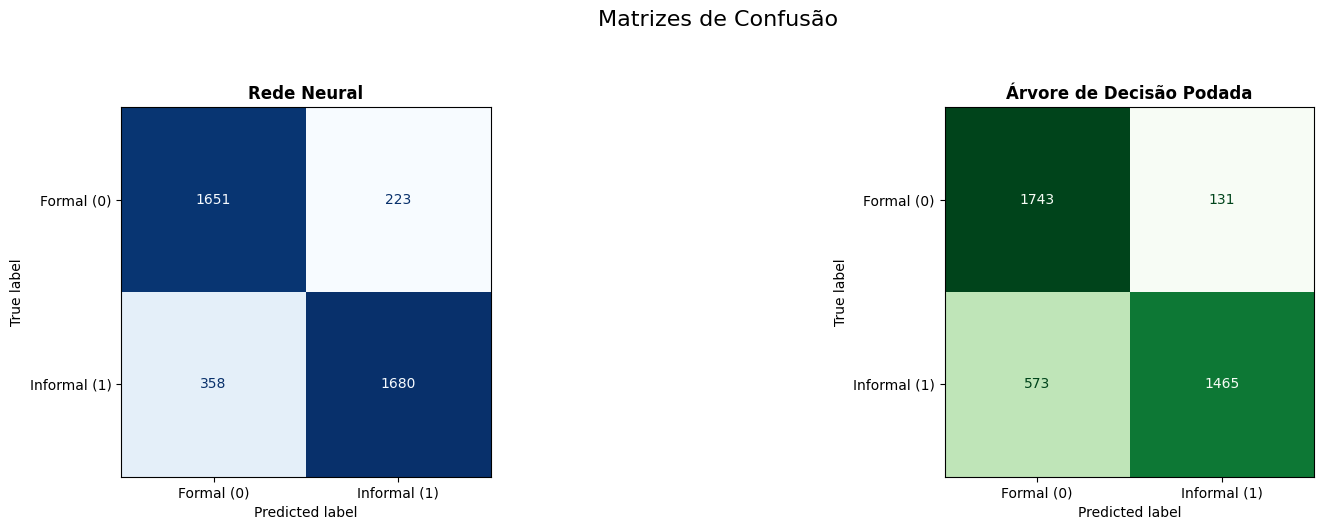

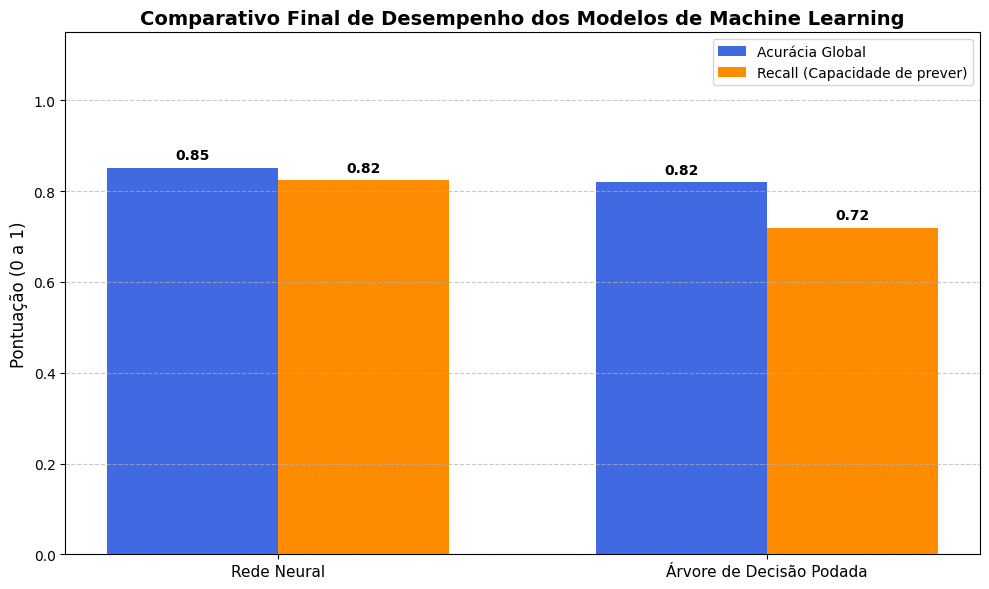

In [105]:
y_pred_nn = (model_final.predict(X_test_processado) > 0.5).astype(int)
y_pred_tree = tree_final.predict(X_test_processado) 

class_names = ['Formal (0)', 'Informal (1)']


fig, axes = plt.subplots(1, 2, figsize=(18, 5))

cm_nn = confusion_matrix(y_test, y_pred_nn)
disp_nn = ConfusionMatrixDisplay(confusion_matrix=cm_nn, display_labels=class_names)
disp_nn.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Rede Neural', fontweight='bold')

cm_tree = confusion_matrix(y_test, y_pred_tree)
disp_tree = ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=class_names)
disp_tree.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Árvore de Decisão Podada', fontweight='bold')

plt.suptitle("Matrizes de Confusão", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()



acc_nn, rec_nn = accuracy_score(y_test, y_pred_nn), recall_score(y_test, y_pred_nn)
acc_tree, rec_tree = accuracy_score(y_test, y_pred_tree), recall_score(y_test, y_pred_tree)

labels = ['Rede Neural', 'Árvore de Decisão Podada']
acuracias = [acc_nn, acc_tree]
recalls = [rec_nn, rec_tree]

x = np.arange(len(labels))  
width = 0.35               

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - width/2, acuracias, width, label='Acurácia Global', color='royalblue')
rects2 = ax.bar(x + width/2, recalls, width, label='Recall (Capacidade de prever)', color='darkorange')

ax.set_ylabel('Pontuação (0 a 1)', fontsize=12)
ax.set_title('Comparativo Final de Desempenho dos Modelos de Machine Learning', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 1.15)
ax.legend(loc='upper right', frameon=True)
ax.grid(axis='y', linestyle='--', alpha=0.7)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 4),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

autolabel(rects1)

autolabel(rects2)

fig.tight_layout()
plt.show()

A rede neural regularizada obteve acurácia de 85,15%, com desempenho equilibrado entre as duas classes: precisão de 0,82 e recall de 0,88 para "Formal", e precisão de 0,88 e recall de 0,82 para "Informal" (F1-score de 0,85 em ambas). Esse equilíbrio reflete a proximidade da matriz de confusão à diagonal principal (1.651 formais e 1.680 informais corretamente classificados, contra 223 e 358 erros, respectivamente) — o modelo não favorece sistematicamente nenhuma das classes.

A árvore de decisão podada, por outro lado, apresentou acurácia ligeiramente inferior (82,00%), mas com um padrão de erro assimétrico entre as classes: recall de 0,93 para "Formal" contra apenas 0,72 para "Informal", enquanto a precisão se inverte (0,75 para "Formal" e 0,92 para "Informal"). Isso significa que a árvore erra bem mais ao tentar identificar trabalhadores informais — de 2.038 casos reais de informalidade, ela deixou passar 573 (28%) como falsos negativos, contra apenas 358 (17,6%) da rede neural. Como o objetivo prático do trabalho é justamente identificar situações de informalidade, esse recall mais baixo é a principal desvantagem da árvore em relação à rede neural, mesmo com F1-score próximo (0,81 contra 0,85).

O Random Forest ficou em posição intermediária (acurácia de 84,10%, recall de 0,82 para "Informal"), superando a árvore individual ao reduzir a variância pela combinação de múltiplas árvores, mas sem alcançar o desempenho da rede neural regularizada nesta base de dados.